In [127]:
import pandas as pd

df = pd.read_csv("../data/raw/healthcare-dataset-stroke-data.csv")

print(df.shape)
df.head()


(5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [128]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [129]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [130]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [131]:
df.dtypes

id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

# Exploratory Data Analysis (EDA)

In this notebook, we perform an exploratory analysis of the Stroke Prediction Dataset to understand its structure, data types, missing values, and feature distributions before generating synthetic healthcare data.

In [132]:
import matplotlib.pyplot as plt

## Dataset Dimensions

In [133]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 5110
Columns: 12


## Missing Values

In [134]:
missing = df.isnull().sum()

missing

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

## Missing Values Visualization

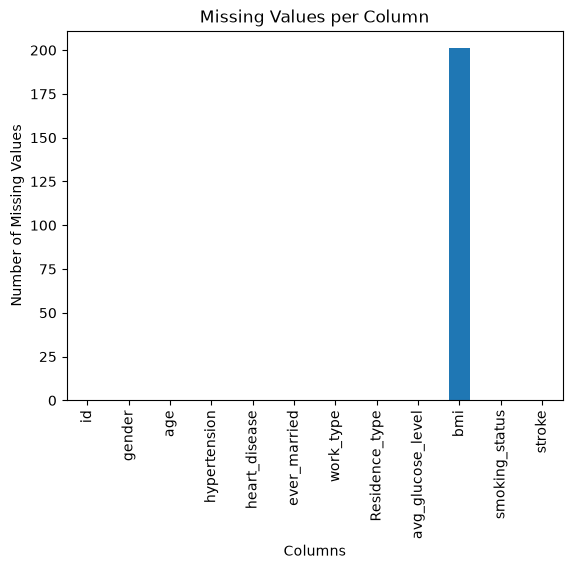

In [135]:
missing.plot(kind="bar")

plt.title("Missing Values per Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.savefig("../figures/missing_values.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation
The analysis of missing values shows that the dataset is generally complete. Only the BMI feature contains missing values (201 records), while all other variables 
are complete. This indicates that only limited preprocessing will be required before applying synthetic data generation techniques.

## Target Variable Distribution

In [136]:
stroke_counts = df["stroke"].value_counts()

stroke_counts

stroke
0    4861
1     249
Name: count, dtype: int64

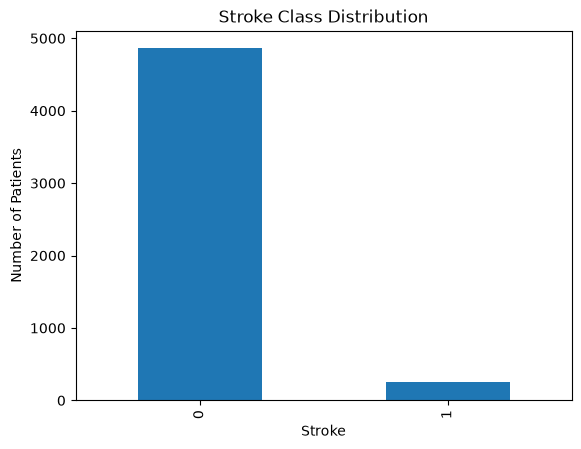

In [137]:
stroke_counts.plot(kind="bar")

plt.title("Stroke Class Distribution")
plt.xlabel("Stroke")
plt.ylabel("Number of Patients")

plt.savefig("../figures/stroke_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

In [138]:
stroke_counts / len(df) * 100

stroke
0    95.127202
1     4.872798
Name: count, dtype: float64

### Interpretation
The target variable is highly imbalanced. Approximately 95.1% of the records belong to the non-stroke class, while only 4.9% correspond to stroke cases.
 This imbalance should be considered during data analysis and when evaluating the quality of the generated synthetic datasets.

## Age Distribution

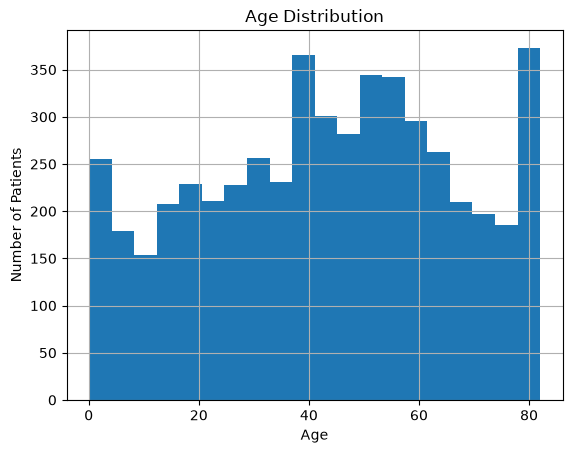

In [139]:
df["age"].hist(bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.savefig("../figures/age_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [140]:
print("Minimum Age :", df["age"].min())
print("Maximum Age :", df["age"].max())
print("Average Age :", round(df["age"].mean(),2))
print("Median Age  :", df["age"].median())

Minimum Age : 0.08
Maximum Age : 82.0
Average Age : 43.23
Median Age  : 45.0


### Interpretation

The age distribution shows that the dataset contains patients of different age groups, ranging from infants to elderly individuals. The average age is approximately 43 years. Understanding the age distribution is important because age is one of the main risk factors associated with stroke. This analysis provides an initial overview of the population represented in the dataset.

## Gender Distribution

In [141]:
gender_counts = df["gender"].value_counts()

gender_counts

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

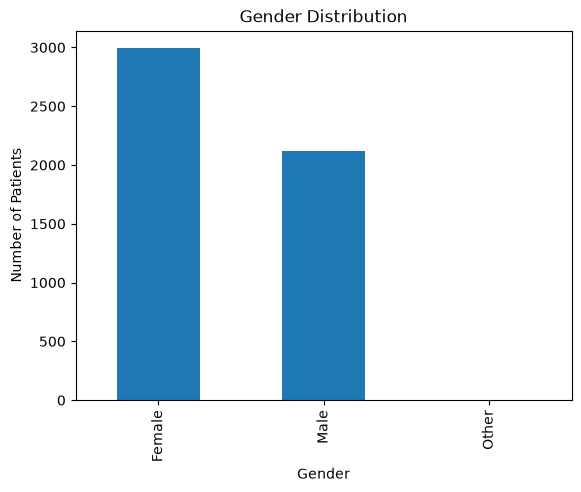

In [142]:
gender_counts.plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

plt.savefig("../figures/gender_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [143]:
gender_counts / len(df) * 100

gender
Female    58.590998
Male      41.389432
Other      0.019569
Name: count, dtype: float64

### Interpretation

The dataset contains both male and female patients, with females representing approximately 58.6% of the observations and males 41.4%. Only one record belongs to the "Other" category, representing a negligible proportion of the dataset. Overall, the gender distribution is relatively balanced and provides sufficient diversity for evaluating synthetic data generation techniques.

## Body Mass Index (BMI) Distribution

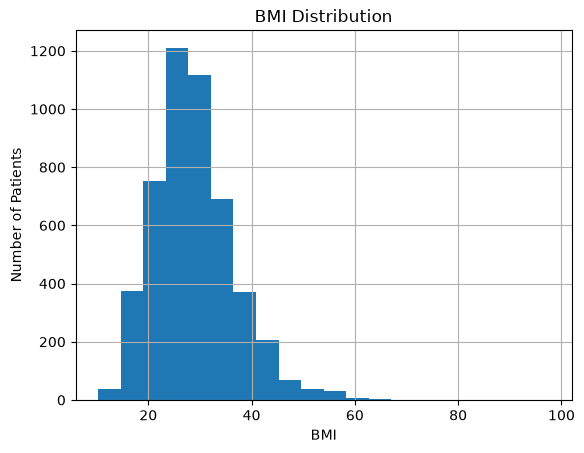

In [144]:
df["bmi"].hist(bins=20)

plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Number of Patients")

plt.savefig("../figures/bmi_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [145]:
print("Minimum BMI :", round(df["bmi"].min(), 2))
print("Maximum BMI :", round(df["bmi"].max(), 2))
print("Average BMI :", round(df["bmi"].mean(), 2))
print("Median BMI  :", round(df["bmi"].median(), 2))

Minimum BMI : 10.3
Maximum BMI : 97.6
Average BMI : 28.89
Median BMI  : 28.1


### Interpretation

The BMI distribution provides an overview of the body mass index of the patients included in the dataset. Since BMI is an important clinical indicator associated with cardiovascular diseases and stroke risk, understanding its distribution is useful before generating synthetic healthcare data.

## Average Glucose Level Distribution

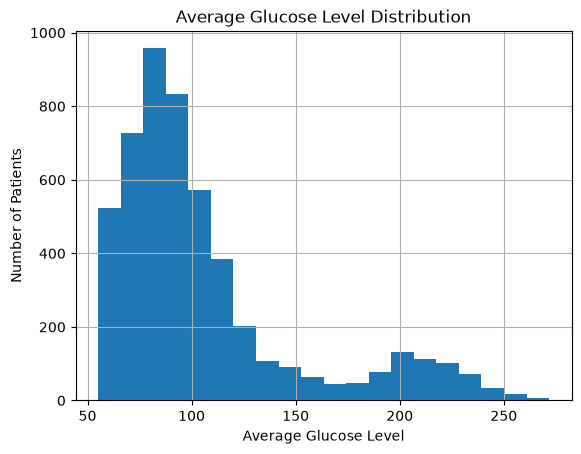

In [146]:
df["avg_glucose_level"].hist(bins=20)

plt.title("Average Glucose Level Distribution")
plt.xlabel("Average Glucose Level")
plt.ylabel("Number of Patients")

plt.savefig("../figures/glucose_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [147]:
print("Minimum Glucose :", round(df["avg_glucose_level"].min(), 2))
print("Maximum Glucose :", round(df["avg_glucose_level"].max(), 2))
print("Average Glucose :", round(df["avg_glucose_level"].mean(), 2))
print("Median Glucose  :", round(df["avg_glucose_level"].median(), 2))

Minimum Glucose : 55.12
Maximum Glucose : 271.74
Average Glucose : 106.15
Median Glucose  : 91.88


### Interpretation

The average glucose level shows the variability of blood glucose measurements among patients. This feature is clinically relevant because abnormal glucose levels are associated with an increased risk of stroke and other cardiovascular conditions.

## Correlation Matrix

In [148]:
correlation = df.corr(numeric_only=True)

correlation

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
id,1.000000,0.003538,0.003550,-0.001296,0.001092,0.003084,0.006388
age,0.003538,1.000000,0.276398,0.263796,0.238171,0.333398,0.245257
hypertension,0.003550,0.276398,1.000000,0.108306,0.174474,0.167811,0.127904
heart_disease,-0.001296,0.263796,0.108306,1.000000,0.161857,0.041357,0.134914
avg_glucose_level,0.001092,0.238171,0.174474,0.161857,1.000000,0.175502,0.131945
bmi,0.003084,0.333398,0.167811,0.041357,0.175502,1.000000,0.042374
stroke,0.006388,0.245257,0.127904,0.134914,0.131945,0.042374,1.000000


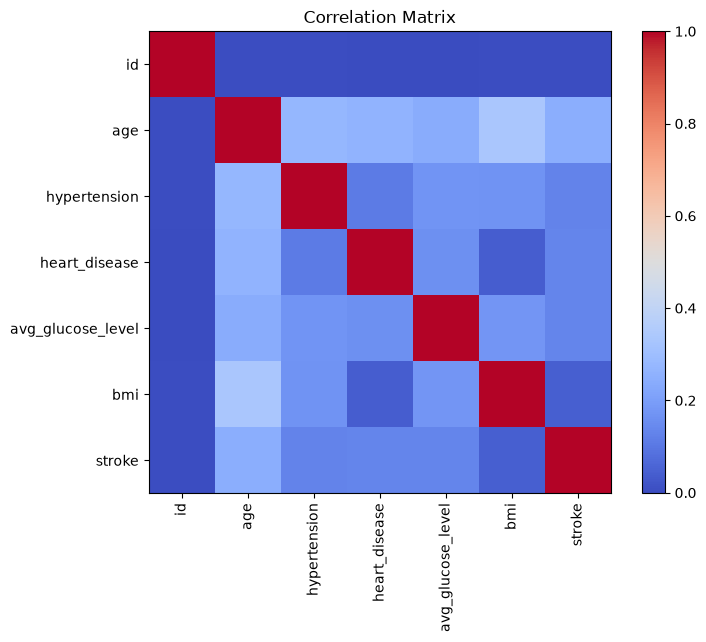

In [149]:
plt.figure(figsize=(8,6))

plt.imshow(correlation, cmap="coolwarm", interpolation="nearest")

plt.colorbar()

plt.xticks(range(len(correlation.columns)),
           correlation.columns,
           rotation=90)

plt.yticks(range(len(correlation.columns)),
           correlation.columns)

plt.title("Correlation Matrix")

plt.savefig("../figures/correlation_matrix.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### Interpretation

The correlation matrix provides an overview of the linear relationships between the numerical variables. Most variables exhibit weak correlations, indicating that each feature contributes different information. This analysis is useful for understanding the dataset before applying synthetic data generation models.

# Dataset Summary

The exploratory data analysis (EDA) provided a comprehensive overview of the Stroke Prediction Dataset.

The main findings are summarized below:

- The dataset contains 5,110 patient records and 12 variables.
- Only the BMI feature contains missing values (201 records), while all other variables are complete.
- The target variable (stroke) is highly imbalanced, with approximately 95.1% of patients belonging to the non-stroke class and 4.9% to the stroke class.
- The dataset includes both numerical and categorical variables, making it suitable for synthetic healthcare data generation.
- The distributions of age, gender, body mass index (BMI), and average glucose level were explored.
- The correlation analysis indicated generally weak linear relationships among the numerical variables.

Overall, the dataset appears suitable for synthetic data generation. The next stage of the project will focus on data preprocessing, handling missing values, and preparing the dataset for synthetic data generation models such as CTGAN, TVAE, and Gaussian Copula.